# GNN + LSTM + PPO со динамичен граф во CityLearn  
Се тренира агент (PPO) кој комбинира **GNN (GATv2)** за граф-контекст меѓу згради и **LSTM** за временска динамика. Користиме **динамичен граф** што се ажурира периодично, така што соседствата меѓу зградите се менуваат според тековните набљудувања.


## Инсталација на компатибилни библиотеки





In [1]:

!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-geometric pyg-lib torch-cluster torch-spline-conv || true

!pip install -q --no-cache-dir torch==2.4.0+cu118 torchvision==0.19.0+cu118 torchaudio==2.4.0+cu118 \
  --index-url https://download.pytorch.org/whl/cu118


!pip install -q --no-cache-dir pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
  -f https://data.pyg.org/whl/torch-2.4.0+cu118.html
!pip install -q --no-cache-dir torch-geometric==2.6.0


!pip install -q --no-deps stable-baselines3==2.2.1
!pip install -q "citylearn==2.3.0" "scikit-learn==1.2.2" "numpy<2.0" "gymnasium==0.29.1" pandas matplotlib

Found existing installation: torch 2.8.0+cu126
Uninstalling torch-2.8.0+cu126:
  Successfully uninstalled torch-2.8.0+cu126
Found existing installation: torchvision 0.23.0+cu126
Uninstalling torchvision-0.23.0+cu126:
  Successfully uninstalled torchvision-0.23.0+cu126
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.7/857.7 MB 60.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 109.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 151.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 95.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 104.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 90.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 97.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━

# Тренирање на една зграда со GNN + LSTM + PPO

Моделот се тренира врз податоци од една зграда со цел да научи како да управува со потрошувачката и складирањето на енергија. Наместо класичен пристап, тука се комбинираат два елементи: **LSTM**, кој ја следи временската динамика на потрошувачката, и **GNN**, кој овозможува да се земе предвид контекстот на целата мрежа на згради. На овој начин се моделира не само однесувањето на конкретната зграда, туку и нејзината поврзаност со другите.

Наградната функција е дефинирана така што го поттикнува намалувањето на потрошувачката во часови со висока цена, користење на соларна енергија кога е достапна и одржување стабилно управување со батеријата.



# Градење на графот

Најважниот дел е начинот на кој се конструира графот. Секој јазол претставува една зграда, а рабовите ги одредуваат сличностите меѓу нив. Соседствата не се статични – тие се ажурираат динамично за време на тренирањето, според најновите податоци за потрошувачка, соларна генерација или други карактеристики. Тоа значи дека поврзаноста меѓу зградите може да се менува низ времето, во зависност од тоа која зграда моментално има најслични обрасци.

Со ваквиот динамичен граф, GNN делот од моделот добива контекст што е во чекор со тековната состојба на системот, што може да помогне агентот подобро да ги донесува одлуките.

# Тренирање и евалуација

Агентот се тренира во CityLearn околината со Phase 1 сценарио. PPO алгоритмот собира искуства во секвенци и ги ажурира политиките со цел да ја подобри наградата. Во текот на процесот, графот периодично се обновува, а со тоа и врските меѓу зградите.

За евалуација се користи една зграда, на која моделот ја применува научената политика. Се бележи вкупната награда и со тоа се следи дали политиката е стабилна или се менува со тек на времето. Графикот на резултати ја покажува просечната награда во функција на бројот на чекори. Ако кривата расте, тоа значи дека агентот се адаптира и успева да извлече повисока награда; ако стагнира или осцилира, тоа укажува на стабилизација или варијабилност поради динамичниот граф; а ако опаѓа, се забележува потешкотија во учењето под новите услови.


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

from gymnasium import Env, spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList

from citylearn.citylearn import CityLearnEnv
from citylearn.reward_function import RewardFunction

print("Torch:", torch.__version__, "| CUDA:", torch.version.cuda, "| CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using", device, "device")


def _oget(o, keys, default=0.0):
    for k in keys:
        if k in o:
            return o[k]
    return default

class CustomReward(RewardFunction):
    def __init__(self, env_metadata):
        super().__init__(env_metadata)


    def calculate(self, observations=None, *args, **kwargs):
        if observations is None:
            observations = kwargs.get('observations', None)
        if observations is None:
            raise ValueError("CustomReward.calculate: 'observations' not provided.")

        rewards = []
        for o in observations:
            net_elec = _oget(o, ['net_electricity_consumption'], 0.0)
            solar    = _oget(o, ['solar_generation'], 0.0)
            soc      = _oget(o, ['electrical_storage_soc','electrical_storage_state_of_charge','soc'], 0.5)
            price    = _oget(o, ['electricity_pricing','electricity_price'], 0.0)

            r = -1.0 * net_elec * price
            r += 0.2 * solar
            if net_elec > 0 and soc < 0.1:
                r -= 0.5
            if soc > 0.9 and net_elec < 0.1 and solar > 0.1:
                r -= 0.3
            r -= 0.05 * abs(soc - 0.5)

            rewards.append(float(np.clip(r, -20.0, 20.0)))
        return rewards


def build_dynamic_graph(env, k=2):
    n = len(env.buildings)
    feats = []
    for b in env.buildings:
        feats.append([
            b.net_electricity_consumption[-1],
            b.solar_generation[-1],
            b.electrical_storage.soc[-1]
        ])
    features = np.array(feats, dtype=np.float32)
    features = StandardScaler().fit_transform(features)
    dists = euclidean_distances(features)

    edge_index, edge_attr = [], []
    for i in range(n):
        nearest = np.argsort(dists[i])[1:k+1]
        for j in nearest:
            w = 1.0 / (dists[i][j] + 1e-6)
            edge_index += [[i, j], [j, i]]
            edge_attr  += [[w], [w]]

    ei = torch.tensor(edge_index, dtype=torch.long).T if len(edge_index) else torch.empty((2,0), dtype=torch.long)
    ea = torch.tensor(edge_attr, dtype=torch.float32) if len(edge_attr) else torch.empty((0,1), dtype=torch.float32)
    return torch.tensor(features, dtype=torch.float32), ei, ea


class CityLearnSingleBuildingWrapper(Env):
    def __init__(self, env, building_id=0, seq_len=12):
        super().__init__()
        self.env = env
        self.building_id = building_id
        self.seq_len = seq_len
        self.n_buildings = len(env.action_space)
        self.obs_dim = env.observation_space[building_id].shape[0]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(seq_len*self.obs_dim,), dtype=np.float32)
        self.buffer = []

    def reset(self, **kwargs):
        obs, _ = self.env.reset(**kwargs)
        self.buffer = []
        o = obs[self.building_id]
        for _ in range(self.seq_len):
            self.buffer.append(o)
        return np.concatenate(self.buffer), {}

    def step(self, action):
        actions = [[0.0] * self.env.action_space[0].shape[0] for _ in range(self.n_buildings)]
        actions[self.building_id] = [float(action[0])]
        obs, reward, terminated, truncated, info = self.env.step(actions)
        o = obs[self.building_id]
        self.buffer.pop(0)
        self.buffer.append(o)
        return np.concatenate(self.buffer), reward[self.building_id], terminated, truncated, info

class GNN_LSTM_FeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, env, hidden_size=64, lstm_layers=1):
        super().__init__(observation_space, features_dim=hidden_size)
        self.hidden_size = hidden_size
        self.obs_dim = observation_space.shape[0] // 12
        self.lstm = nn.LSTM(self.obs_dim, hidden_size, lstm_layers, batch_first=True)
        self.hidden = None
        self.env = env
        self.building_id = env.building_id if hasattr(env, 'building_id') else 0
        self.graph_x = torch.zeros((len(env.buildings), 3), dtype=torch.float32)
        self.edge_index = torch.empty((2, 0), dtype=torch.long)
        self.edge_attr = torch.empty((0, 1), dtype=torch.float32)
        self.gnn1 = GATv2Conv(3, hidden_size, edge_dim=1)
        self.gnn2 = GATv2Conv(hidden_size, hidden_size, edge_dim=1)

    def update_graph(self):
        gx, ei, ea = build_dynamic_graph(self.env)
        self.graph_x, self.edge_index, self.edge_attr = gx, ei, ea

    def forward(self, obs):
        bsz = obs.shape[0]
        x = obs.view(bsz, 12, self.obs_dim).float()
        if self.hidden is None or self.hidden[0].shape[1] != bsz:
            h0 = torch.zeros(self.lstm.num_layers, bsz, self.hidden_size, device=x.device)
            c0 = torch.zeros(self.lstm.num_layers, bsz, self.hidden_size, device=x.device)
            self.hidden = (h0, c0)
        lstm_out, self.hidden = self.lstm(x, self.hidden)
        self.hidden = (self.hidden[0].detach(), self.hidden[1].detach())
        lstm_feat = lstm_out[:, -1, :]

        gx = self.graph_x.to(x.device)
        ei = self.edge_index.to(x.device)
        ea = self.edge_attr.to(x.device)
        if ei.numel() > 0:
            gx = torch.relu(self.gnn1(gx, ei, ea))
            gx = torch.relu(self.gnn2(gx, ei, ea))
            gnn_feat = gx[self.building_id].unsqueeze(0).expand(bsz, -1)
        else:
            gnn_feat = torch.zeros_like(lstm_feat)

        return lstm_feat + gnn_feat


class CustomGNNLSTMPolicy(ActorCriticPolicy):
    def __init__(self, observation_space, action_space, lr_schedule, env, **kwargs):
        super().__init__(
            observation_space, action_space, lr_schedule,
            features_extractor_class=GNN_LSTM_FeatureExtractor,
            features_extractor_kwargs={"env": env},
            **kwargs
        )


class DynamicGraphCallback(BaseCallback):
    def __init__(self, every_n_env_steps=24, verbose=0):
        super().__init__(verbose)
        self.every_n_env_steps = every_n_env_steps
        self._last_update = -1

    def _on_training_start(self) -> None:
        self.model.policy.features_extractor.update_graph()
        self._last_update = self.num_timesteps

    def _on_step(self) -> bool:
        if (self.num_timesteps - self._last_update) >= self.every_n_env_steps:
            self.model.policy.features_extractor.update_graph()
            self._last_update = self.num_timesteps
        return True


env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)


def make_train_env():
    return Monitor(CityLearnSingleBuildingWrapper(env, building_id=0, seq_len=12), filename=None)

vec_env = VecMonitor(DummyVecEnv([make_train_env]), filename=None)

def make_eval_env():
    return Monitor(CCityLearnSingleBuildingWrapper(env, building_id=0, seq_len=12), filename=None)


class CCityLearnSingleBuildingWrapper(CityLearnSingleBuildingWrapper):
    pass

eval_env = VecMonitor(DummyVecEnv([lambda: CCityLearnSingleBuildingWrapper(env, building_id=0, seq_len=12)]), filename=None)


model = PPO(
    CustomGNNLSTMPolicy,
    vec_env,
    device=device,
    n_steps=1024,
    batch_size=32,
    learning_rate=5e-5,
    gamma=0.99,
    gae_lambda=0.9,
    ent_coef=0.01,
    vf_coef=0.9,
    max_grad_norm=0.3,
    normalize_advantage=False,
    policy_kwargs={"env": env},
    tensorboard_log="./logs/tb"
)



model.policy.features_extractor.update_graph()


eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./logs/best_model",
    log_path="./logs/eval",
    eval_freq=4096,
    n_eval_episodes=1,
    deterministic=True,
    render=False
)


dg_callback = DynamicGraphCallback(every_n_env_steps=24)
callbacks = CallbackList([dg_callback, eval_callback])


model.learn(total_timesteps=500_000, callback=callbacks, log_interval=10)
model.save("ppo_gnn_lstm_dynamic_graph")

print("Training finished. TensorBoard logs in ./logs/tb")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO:root:The dataset names DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.3.0 GitHub repository and write to /root/.cache/citylearn/v2.3.0/dataset_names.json. Next time DataSet.get_dataset_names is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:T

Torch: 2.4.0+cu118 | CUDA: 11.8 | CUDA available: False
Using cpu device


INFO:root:The PV sizing data DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.3.0 GitHub repository and write to /root/.cache/citylearn/v2.3.0/misc. Next time DataSet.get_pv_sizing_data is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:The battery sizing data DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.3.0 GitHub repository and write to /root/.cache/citylearn/v2.3.0/misc. Next time DataSet.get_battery_sizing_data is called, it will read from cache unless DataSet.clear_cache is run first.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/vec_monito

Eval num_timesteps=4096, episode_reward=-3277.08 +/- 0.00
Episode length: 8759.00 +/- 0.00
New best mean reward!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Eval num_timesteps=364544, episode_reward=-677.56 +/- 0.00
Episode length: 8759.00 +/- 0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Генерализација на повеќе згради

По завршувањето на тренирањето, моделот не се тестира само на зградата на која е обучен, туку и на други згради. Целта е да се види колку политиката може да се пренесе во нови услови. Секој тест враќа вкупна награда за соодветната зграда.  

Доколку наградите се приближно слични, тоа значи дека политиката е генерална и може да се применува на различни профили на згради. Ако се забележуваат големи разлики, тоа укажува дека политиката е поспецифична и зависи од карактеристиките на зградата на која е тренирана.



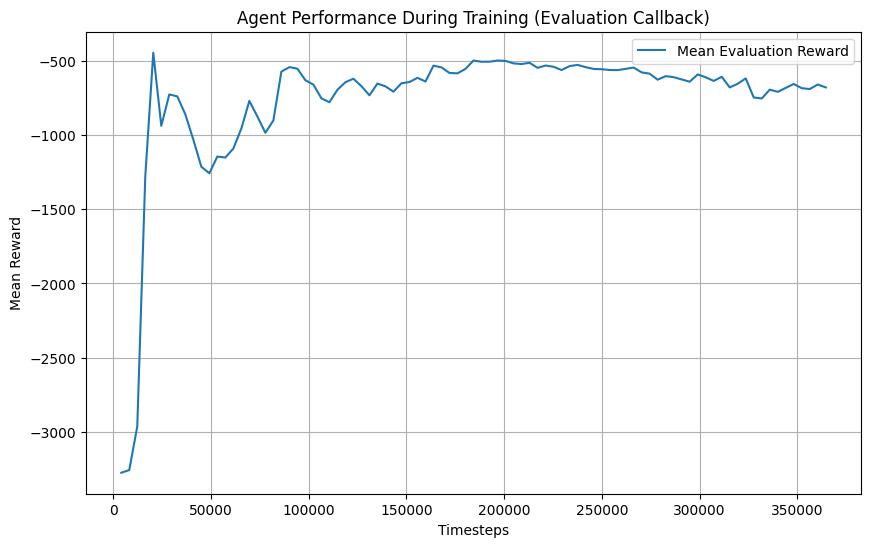

✅ Loaded 89 evaluation points.
First 5 timesteps: [ 4096  8192 12288 16384 20480]
First 5 mean rewards: [-3277.083  -3259.1772 -2964.8857 -1278.6404  -443.313 ]
Shape of 'results' array: (89, 1)


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import os


eval_data_path = '/content/logs/eval/evaluations_DynamicGraph.npz'

try:

    data = np.load(eval_data_path)


    timesteps = data['timesteps']
    results = data['results']


    mean_rewards = np.mean(results, axis=1)




    plt.figure(figsize=(10, 6))
    plt.plot(timesteps, mean_rewards, label='Mean Evaluation Reward')
    plt.title('Agent Performance During Training (Evaluation Callback)')
    plt.xlabel('Timesteps')
    plt.ylabel('Mean Reward')
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"✅ Loaded {len(timesteps)} evaluation points.")
    print(f"First 5 timesteps: {timesteps[:5]}")
    print(f"First 5 mean rewards: {mean_rewards[:5]}")
    print(f"Shape of 'results' array: {results.shape}")

except FileNotFoundError:
    print(f"❌ Error: evaluations.npz not found at {eval_data_path}")
    print("Please ensure the path is correct and the EvalCallback was configured to save this file.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")
    print(f"Keys available in npz: {list(data.keys())}")

In [7]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 2
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("/content/logs/best_model/best_model")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.load(file_content, map_locati

📊 Total reward on unseen building 2: 6.29


In [8]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 1
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("/content/logs/best_model/best_model")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.load(file_content, map_locati

📊 Total reward on unseen building 1: -911.14


In [9]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 3
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("/content/logs/best_model/best_model")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.load(file_content, map_locati

📊 Total reward on unseen building 3: -885.03


In [10]:
from stable_baselines3 import PPO

env = CityLearnEnv(
    schema='citylearn_challenge_2022_phase_1',
    reward_function=CustomReward,
    central_agent=False
)

test_building_id = 4
eval_env = CityLearnSingleBuildingWrapper(env, building_id=test_building_id, seq_len=12)

model = PPO.load("/content/logs/best_model/best_model")

obs, _ = eval_env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = eval_env.step(action)
    total_reward += reward

print(f"📊 Total reward on unseen building {test_building_id}: {total_reward:.2f}")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:449: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  th_object = th.load(file_content, map_locati

📊 Total reward on unseen building 4: -485.28


# Улогата на динамичниот граф

Воведувањето на динамичен граф има двоен ефект. Од една страна, тој овозможува графот да ја рефлектира моменталната состојба и да го насочува агентот со информации што се пореални и адаптивни. Од друга страна, честите промени можат да донесат нестабилност во процесот на учење и да создадат варијабилност во наградата.

Затоа, графиките и резултатите од евалуацијата треба да се читаат внимателно како опис на тоа што се случува: дали динамичниот граф му помогнал на агентот да се подобри или пак довел до осцилации во перформансот.
